In [1]:
import numpy as np
# NumPy is a Python library mainly used for fast numerical computing

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [2]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    r"D:\Selflearning\CatsAndDogs\Pics\train",
    transform = transform
)

test_dataset = datasets.ImageFolder(
    r"D:\Selflearning\CatsAndDogs\Pics\test",
    transform = transform
)

In [3]:
def dataset_to_numpy(dataset):
    X = []
    y = []

    for image, label in dataset:
        X.append(image.numpy().flatten())
        y.append(label)

    return np.array(X), np.array(y)

X_train, y_train = dataset_to_numpy(train_dataset)
X_test, y_test = dataset_to_numpy(test_dataset)

In [4]:
print(X_train.shape)
print(y_train.shape)

(4, 12288)
(4,)


In [5]:
model = LogisticRegression(max_iter=3)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

C:\Users\zhang\miniconda3\envs\ML12\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Machine learning methods: LR, KNN, DT, SVM

In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=3),
    "KNN": KNeighborsClassifier(n_neighbors=2),
    "Decision Tree": DecisionTreeClassifier(max_depth=1),
    "SVM": SVC(kernel="linear")
}

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    print(name, accuracy)

Logistic Regression 0.5


C:\Users\zhang\miniconda3\envs\ML12\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\zhang\miniconda3\envs\ML12\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系统找不到指定的文件。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\zhang\miniconda3\

KNN 0.5
Decision Tree 0.75
SVM 0.5


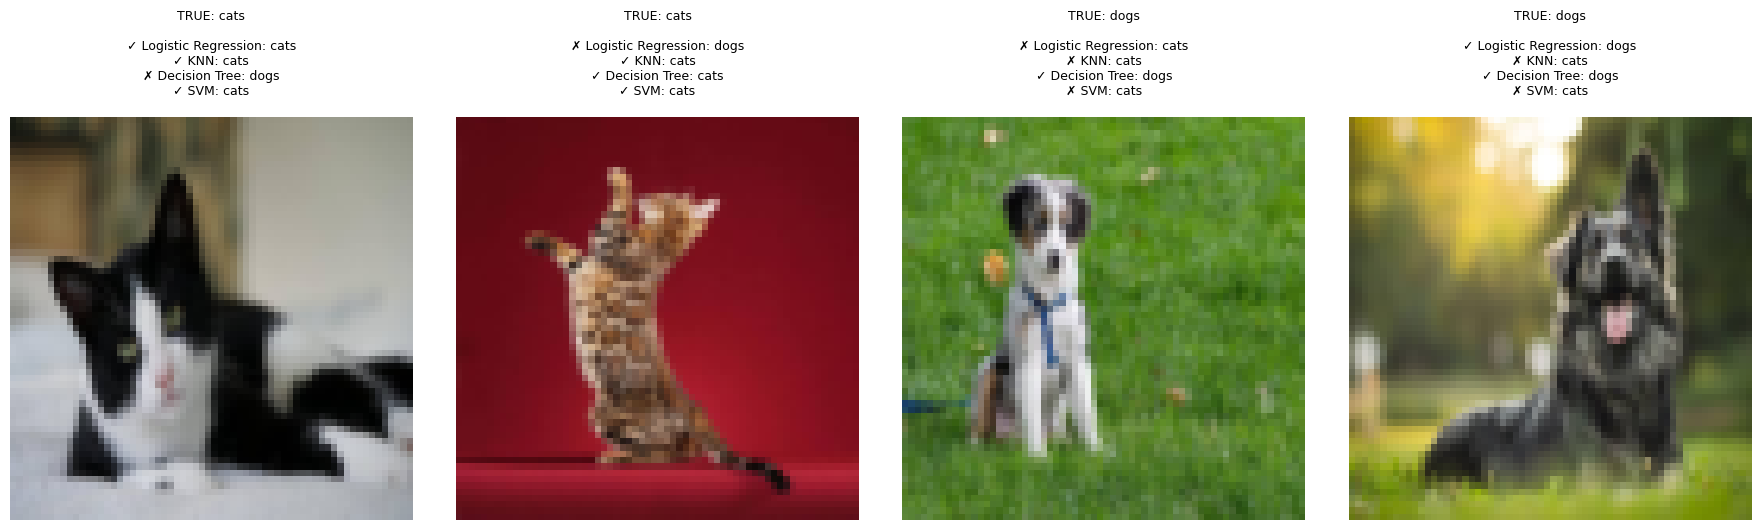

In [7]:
import matplotlib.pyplot as plt

class_names = test_dataset.classes

fig, axes = plt.subplots(
    1,
    len(test_dataset),
    figsize=(18, 5)
)

for i, (image, true_label) in enumerate(test_dataset):

    x = image.numpy().flatten().reshape(1, -1)

    true_name = class_names[true_label]

    title = f"TRUE: {true_name}\n\n"

    for name, model in models.items():

        pred = model.predict(x)[0]
        pred_name = class_names[pred]

        mark = "✓" if pred == true_label else "✗"

        title += f"{mark} {name}: {pred_name}\n"

    axes[i].imshow(image.permute(1, 2, 0))
    axes[i].set_title(title, fontsize=9)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

### Vision-language model

In [8]:
import torch
import torchvision

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("CUDA:", torch.version.cuda)

torch: 2.11.0+cpu
torchvision: 0.26.0+cpu
CUDA: None


In [9]:
from transformers import AutoProcessor, AutoModelForImageTextToText
from PIL import Image

In [10]:
model_id = "HuggingFaceTB/SmolVLM2-500M-Video-Instruct"

processor = AutoProcessor.from_pretrained(model_id)

model = AutoModelForImageTextToText.from_pretrained(
    model_id,
    torch_dtype = torch.float16,
    device_map="auto"
)

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
C:\Users\zhang\miniconda3\envs\ML12\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\zhang\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.03GB            

model.safetensors: downloading bytes:           |  0.00B            

C:\Users\zhang\miniconda3\envs\ML12\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\zhang\.cache\huggingface\hub\models--HuggingFaceTB--SmolVLM2-500M-Video-Instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

In [18]:
image = Image.open(r"D:\Selflearning\CatsAndDogs\Pics\test\cats\cat4.jpg").convert("RGB")

messages = [
    {
        "role": "user",
        "content":[
            {"type": "image"},
            {
                "type":"text",
                "text":"Is this a cat or a dog? Answer only: cat or dog."
            }
        ]
    }
]

prompt = processor.apply_chat_template(
    messages,
    add_generation_prompt=True
)

inputs = processor(
    text=prompt,
    images=[image],
    return_tensors="pt"
).to(model.device)

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


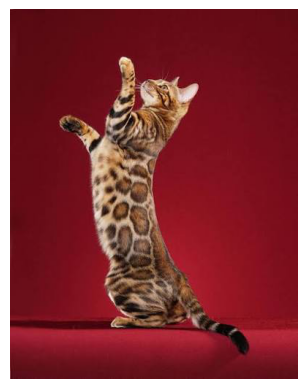

In [19]:
plt.imshow(image)
plt.axis("off")
plt.show()

In [15]:
with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=10
    )

In [16]:
answer = processor.batch_decode(
    output,
    skip_special_tokens=True
)[0]

print(answer)

User:




Is this a cat or a dog? Answer only: cat or dog.
Assistant: cat.
